# Does Predicted Volatility Actually Improve the Portfolio?

This notebook answers the central research question of the project with a direct, controlled test:

1. **Forecast level** — Does the Random Forest predict future 20-day volatility better than a simple
   historical-volatility baseline (just using an asset's trailing 20-day volatility as the forecast)?
2. **Portfolio level** — When we feed predicted volatility into portfolio optimization, do we get a
   *better portfolio* than we get from historical volatility, or from a naive equal-weight portfolio?

Question 2 is the one that matters. A model can win on RMSE and still be useless if the improvement
does not survive being turned into portfolio weights.

## Why this notebook exists (and how it differs from notebook 06)

`06_portfolio_optimization` compares an RF-based portfolio against historical portfolios, but it builds
the RF portfolio from **a single prediction date** and then holds those weights fixed for the entire
two-year test period. Its own markdown says so: *"For this simple version so far, we use the first
available Random Forest prediction date."*

That design cannot answer our question. The Random Forest forecasts volatility **20 trading days**
ahead, but notebook 06 asks one forecast to carry a portfolio for **~500 trading days**. Whatever the
result, it mostly measures how lucky one day's forecast was, not whether the model adds value.

This notebook fixes that by **rebalancing at the model's native 20-day horizon**, so the forecast is
actually used the way it was trained to be used, and by testing whether the result is stable across
rebalancing frequencies.

## Design rules we follow

- **No look-ahead.** Every input at rebalance date `t` uses only data available at `t`.
- **Change one thing at a time.** The matched historical baseline uses the *identical* covariance
  construction as the RF portfolio; only the volatility input differs. That isolates the model's
  contribution.
- **Report what we find.** The honest answer here is mixed, and the mixed answer is the finding.

## Key findings (summary)

| Question | Answer |
|---|---|
| Does RF beat the trailing-20d-vol baseline at forecasting? | **Yes, clearly.** ~19% lower MAE, better on 20 of 21 tickers, statistically significant. |
| Is that mostly ranking assets, or timing each asset? | **Mostly ranking.** RF is much better at knowing *which* assets are risky; its ability to time one asset's volatility is weak but still better than the baseline. |
| Does the RF risk model build lower-volatility portfolios than the matched baseline? | **Yes, consistently** — lower realized volatility at every rebalancing frequency tested. |
| Does that translate into a better Sharpe ratio? | **No, not reliably.** The Sharpe advantage flips sign depending on rebalancing frequency. |
| Does any optimized portfolio beat naive equal-weight on Sharpe? | **No.** Equal-weight wins on risk-adjusted return over this period. |

The takeaway for the report: predicted volatility **does** improve risk control, which is what a
minimum-volatility objective is built to deliver. It does **not** reliably improve risk-adjusted
return, and a simple equal-weight portfolio remains a hard baseline to beat.

# Setup

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from scipy import stats
from scipy.optimize import minimize

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## Paths

In [2]:
INTEGRATED_DATA_PATH = Path("../../data/processed/integrated")
MODELING_PATH = Path("../../data/processed/modeling")
FEATURES_PATH = Path("../../data/processed/features")
OUTPUT_PATH = Path("../../data/processed/predictive_vs_historical")

OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

## Settings

`REBALANCE_EVERY = 20` is deliberate: it matches the model's forecast horizon. The model predicts
volatility over the next 20 trading days, so we refresh the portfolio every 20 trading days.

In [3]:
TRADING_DAYS = 252          # trading days per year, for annualizing
BENCHMARK = "SPY"           # held out of the optimized universe, used as the market benchmark
MAX_WEIGHT = 0.25           # no single asset above 25%, keeps portfolios diversified
REBALANCE_EVERY = 20        # rebalance cadence in trading days = model forecast horizon
CORRELATION_WINDOW = 252    # trailing window used to estimate correlations at each rebalance
TEST_START = "2024-01-01"   # matches the modeling notebooks' train/test split

# Load Data

## Random Forest test predictions

This file has, for each date and ticker, the **actual** realized forward 20-day volatility and the
model's **predicted** forward 20-day volatility over the test period.

In [4]:
rf_predictions = pd.read_csv(
    MODELING_PATH / "random_forest" / "test_predictions.csv",
    parse_dates=["Date"]
)

rf_predictions.head()

,Date,ticker,future_volatility_20d,predicted_future_volatility_20d
0,2024-01-02,MSFT,0.0104,0.0130
1,2024-01-02,PG,0.0117,0.0093
2,2024-01-02,CAT,0.0151,0.0148
3,2024-01-02,AGG,0.0034,0.0043
4,2024-01-02,KO,0.0061,0.0092


## Historical-volatility baseline

Our baseline forecast is the simplest thing a person could do without any model: *assume the next 20
days look like the last 20 days.* That is exactly the `rolling_volatility_20d` feature, which is a
**trailing** window, so using it as a forecast introduces no look-ahead.

This is the same baseline used in the modeling notebooks, which keeps this notebook consistent with
`05_model_comparison`.

In [5]:
features = pd.read_csv(
    FEATURES_PATH / "feature_engineered_dataset.csv",
    parse_dates=["Date"],
    usecols=["Date", "ticker", "rolling_volatility_20d"]
)

features.head()

,Date,ticker,rolling_volatility_20d
0,2018-01-31,AAPL,0.0095
1,2018-02-01,AAPL,0.0095
2,2018-02-02,AAPL,0.0132
3,2018-02-05,AAPL,0.0136
4,2018-02-06,AAPL,0.0172


## Daily market data

In [6]:
daily_market_data = pd.read_csv(
    INTEGRATED_DATA_PATH / "daily_market_data.csv",
    parse_dates=["Date"]
)

daily_market_data.head()

,Date,ticker,adjusted_close,daily_return,risk_free_rate_pct,risk_free_rate_decimal,vix,treasury_10yr_pct,yield_curve_spread,is_inverted,fed_funds_rate_pct,unemployment_rate_pct,recession_flag,cpi_index,cpi_pct_change,company_name,gics_sector,asset_type
0,2018-01-02,AAPL,40.2671,NaN,1.4400,0.0144,9.7700,2.4600,1.0200,0,1.4100,4.0000,0.0000,248.8590,0.0043,Apple Inc.,Information Technology,Stock
1,2018-01-03,AAPL,40.2601,-0.0002,1.4100,0.0141,9.1500,2.4400,1.0300,0,1.4100,4.0000,0.0000,248.8590,0.0043,Apple Inc.,Information Technology,Stock
2,2018-01-04,AAPL,40.4471,0.0046,1.4100,0.0141,9.2200,2.4600,1.0500,0,1.4100,4.0000,0.0000,248.8590,0.0043,Apple Inc.,Information Technology,Stock
3,2018-01-05,AAPL,40.9076,0.0114,1.3900,0.0139,9.2200,2.4700,1.0800,0,1.4100,4.0000,0.0000,248.8590,0.0043,Apple Inc.,Information Technology,Stock
4,2018-01-08,AAPL,40.7556,-0.0037,1.4500,0.0145,9.5200,2.4900,1.0400,0,1.4100,4.0000,0.0000,248.8590,0.0043,Apple Inc.,Information Technology,Stock


## Combine predictions with the baseline

One row per (date, ticker) holding the actual outcome, the RF forecast, and the baseline forecast,
so every comparison below is on exactly the same observations.

In [7]:
forecasts = rf_predictions.merge(features, on=["Date", "ticker"], how="left")

forecasts = forecasts.dropna(
    subset=[
        "future_volatility_20d",
        "predicted_future_volatility_20d",
        "rolling_volatility_20d",
    ]
)

print(f"rows: {len(forecasts):,}")
print(f"tickers: {forecasts['ticker'].nunique()}")
print(f"date range: {forecasts['Date'].min().date()} -> {forecasts['Date'].max().date()}")

forecasts.head()

rows: 10,101
tickers: 21
date range: 2024-01-02 -> 2025-12-01


,Date,ticker,future_volatility_20d,predicted_future_volatility_20d,rolling_volatility_20d
0,2024-01-02,MSFT,0.0104,0.0130,0.0094
1,2024-01-02,PG,0.0117,0.0093,0.0129
2,2024-01-02,CAT,0.0151,0.0148,0.0168
3,2024-01-02,AGG,0.0034,0.0043,0.0046
4,2024-01-02,KO,0.0061,0.0092,0.0082


## Look-ahead check

Before trusting anything below, we confirm the baseline really is trailing. We recompute a 20-day
trailing standard deviation of daily returns directly and check it matches the stored feature. If the
stored feature had been centered or forward-looking, this check would fail and every result would be
contaminated.

In [8]:
check_ticker = "AAPL"

recomputed = (
    daily_market_data[daily_market_data["ticker"] == check_ticker]
    .sort_values("Date")
    .set_index("Date")["daily_return"]
    .rolling(20)
    .std()
)

stored = (
    features[features["ticker"] == check_ticker]
    .set_index("Date")["rolling_volatility_20d"]
)

comparison = pd.concat(
    [recomputed.rename("recomputed_trailing"), stored.rename("stored_feature")],
    axis=1
).dropna()

max_difference = (comparison["recomputed_trailing"] - comparison["stored_feature"]).abs().max()

print(f"max absolute difference: {max_difference:.2e}")
print("PASS - baseline is trailing, no look-ahead" if max_difference < 1e-10 else "FAIL - investigate")

max absolute difference: 1.04e-16
PASS - baseline is trailing, no look-ahead


# Part A: Does the Random Forest Beat the Historical Baseline?

Before asking whether predicted volatility helps a portfolio, we need to know whether the prediction
is actually better than the naive alternative.

## Accuracy metrics

In [9]:
def forecast_metrics(actual, predicted):
    error = predicted - actual
    mae = np.abs(error).mean()
    rmse = np.sqrt((error ** 2).mean())
    r2 = 1 - (error ** 2).sum() / ((actual - actual.mean()) ** 2).sum()

    return {"MAE": mae, "RMSE": rmse, "R2": r2}

In [10]:
actual_volatility = forecasts["future_volatility_20d"]

accuracy = pd.DataFrame([
    {"forecast": "Random Forest",
     **forecast_metrics(actual_volatility, forecasts["predicted_future_volatility_20d"])},
    {"forecast": "Historical baseline (trailing 20d vol)",
     **forecast_metrics(actual_volatility, forecasts["rolling_volatility_20d"])},
])

accuracy

,forecast,MAE,RMSE,R2
0,Random Forest,0.0037,0.0058,0.3390
1,Historical baseline (trailing 20d vol),0.0046,0.0071,0.0015


In [11]:
mae_improvement = 1 - accuracy.loc[0, "MAE"] / accuracy.loc[1, "MAE"]
rmse_improvement = 1 - accuracy.loc[0, "RMSE"] / accuracy.loc[1, "RMSE"]

print(f"RF reduces MAE by  {mae_improvement:.1%} vs the historical baseline")
print(f"RF reduces RMSE by {rmse_improvement:.1%} vs the historical baseline")

RF reduces MAE by  19.5% vs the historical baseline
RF reduces RMSE by 18.6% vs the historical baseline


## Is the improvement statistically significant?

A paired test on squared forecast errors. One caution: our forecasts use **overlapping** 20-day
windows, so consecutive observations are heavily autocorrelated and a naive pooled t-test badly
overstates significance. We therefore also report a test on **daily averages**, which is the more
honest number.

In [12]:
squared_error_rf = (forecasts["predicted_future_volatility_20d"] - actual_volatility) ** 2
squared_error_baseline = (forecasts["rolling_volatility_20d"] - actual_volatility) ** 2

error_difference = squared_error_baseline - squared_error_rf   # positive => RF better

naive_test = stats.ttest_1samp(error_difference, 0)
clustered_test = stats.ttest_1samp(error_difference.groupby(forecasts["Date"]).mean(), 0)

print(f"mean error difference: {error_difference.mean():.3e}  (positive favors RF)")
print(f"RF has lower squared error on {(error_difference > 0).mean():.1%} of observations")
print()
print(f"naive pooled t-test:      t = {naive_test.statistic:6.2f}   p = {naive_test.pvalue:.2e}   <- overstated")
print(f"date-clustered t-test:    t = {clustered_test.statistic:6.2f}   p = {clustered_test.pvalue:.2e}   <- use this one")

mean error difference: 1.718e-05  (positive favors RF)
RF has lower squared error on 57.4% of observations

naive pooled t-test:      t =  17.71   p = 3.94e-69   <- overstated
date-clustered t-test:    t =  11.67   p = 7.01e-28   <- use this one


## Per-ticker breakdown

A pooled average can hide a model that wins on a couple of assets and loses everywhere else. This
checks how broad the improvement is.

In [13]:
per_ticker_rows = []

for ticker, group in forecasts.groupby("ticker"):
    rf_metrics = forecast_metrics(group["future_volatility_20d"], group["predicted_future_volatility_20d"])
    baseline_metrics = forecast_metrics(group["future_volatility_20d"], group["rolling_volatility_20d"])

    per_ticker_rows.append({
        "ticker": ticker,
        "rmse_rf": rf_metrics["RMSE"],
        "rmse_baseline": baseline_metrics["RMSE"],
        "rmse_improvement": 1 - rf_metrics["RMSE"] / baseline_metrics["RMSE"],
        "rf_wins": rf_metrics["RMSE"] < baseline_metrics["RMSE"],
    })

per_ticker = pd.DataFrame(per_ticker_rows).sort_values("rmse_improvement", ascending=False)

print(f"RF beats the baseline on {per_ticker['rf_wins'].sum()} of {len(per_ticker)} tickers")

per_ticker

RF beats the baseline on 20 of 21 tickers


,ticker,rmse_rf,rmse_baseline,rmse_improvement,rf_wins
3,CAT,0.0069,0.0090,0.2369,True
13,SPY,0.0051,0.0066,0.2365,True
4,GLD,0.0036,0.0048,0.2359,True
16,V,0.0049,0.0064,0.2254,True
12,QQQ,0.0056,0.0072,0.2206,True
0,AAPL,0.0075,0.0096,0.2202,True
5,JPM,0.0063,0.0081,0.2187,True
9,MSFT,0.0048,0.0061,0.2163,True
7,LLY,0.0099,0.0125,0.2140,True
2,AMZN,0.0074,0.0093,0.2082,True


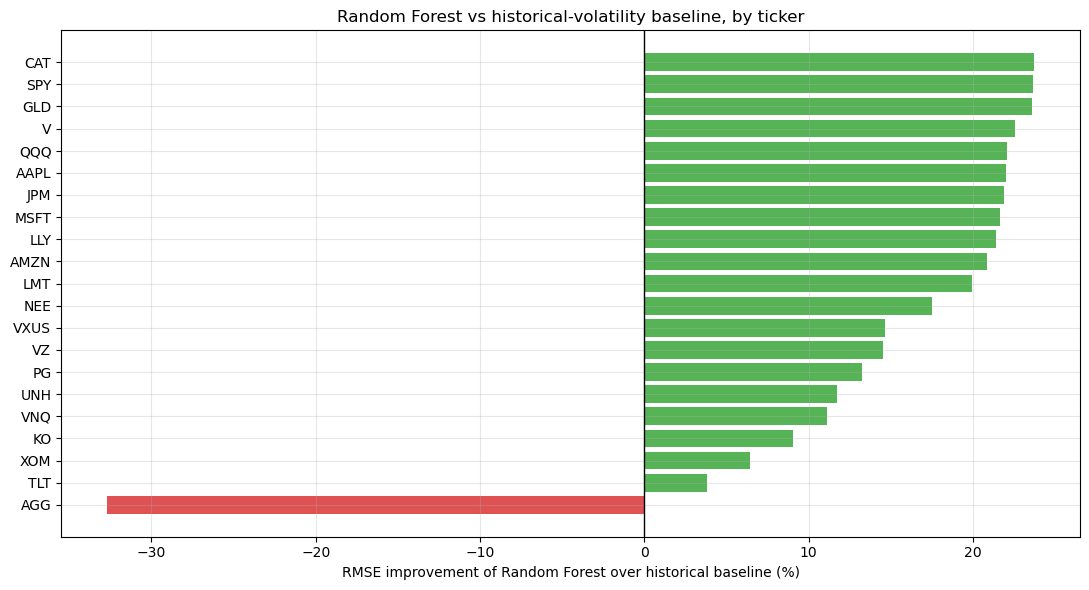

In [14]:
fig, ax = plt.subplots(figsize=(11, 6))

colors = ["tab:green" if wins else "tab:red" for wins in per_ticker["rf_wins"]]
ax.barh(per_ticker["ticker"], per_ticker["rmse_improvement"] * 100, color=colors, alpha=0.8)

ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("RMSE improvement of Random Forest over historical baseline (%)")
ax.set_title("Random Forest vs historical-volatility baseline, by ticker")
ax.invert_yaxis()

plt.tight_layout()
plt.show()

## Where does the skill actually come from?

This is the most important caveat in Part A, and it is easy to miss.

Pooled R² of ~0.34 sounds strong, but pooled R² rewards two very different abilities:

- **Cross-sectional skill** — knowing that UNH is riskier than AGG *today*. Easy, and largely a
  matter of learning each asset's typical volatility level.
- **Time-series skill** — knowing that a *given* asset's volatility is about to rise or fall. Hard,
  and far more valuable.

We separate them. Removing each ticker's mean isolates pure time-series skill; per-date rank
correlation across tickers isolates cross-sectional skill.

In [15]:
def r2_score(actual, predicted):
    return 1 - ((predicted - actual) ** 2).sum() / ((actual - actual.mean()) ** 2).sum()


# time-series skill: demean every column within ticker, removing level differences between assets
demeaned = forecasts.copy()
grouped = forecasts.groupby("ticker")

for column in ["future_volatility_20d", "predicted_future_volatility_20d", "rolling_volatility_20d"]:
    demeaned[column] = forecasts[column] - grouped[column].transform("mean")

within_ticker_rf = r2_score(demeaned["future_volatility_20d"], demeaned["predicted_future_volatility_20d"])
within_ticker_baseline = r2_score(demeaned["future_volatility_20d"], demeaned["rolling_volatility_20d"])

# cross-sectional skill: on each date, how well is the ranking of assets by risk reproduced
rank_correlation_rf = []
rank_correlation_baseline = []

for date, group in forecasts.groupby("Date"):
    if len(group) > 5:
        rank_correlation_rf.append(
            stats.spearmanr(group["future_volatility_20d"], group["predicted_future_volatility_20d"]).statistic
        )
        rank_correlation_baseline.append(
            stats.spearmanr(group["future_volatility_20d"], group["rolling_volatility_20d"]).statistic
        )

skill = pd.DataFrame([
    {"skill_type": "Pooled R2 (both effects combined)",
     "random_forest": r2_score(actual_volatility, forecasts["predicted_future_volatility_20d"]),
     "baseline": r2_score(actual_volatility, forecasts["rolling_volatility_20d"])},
    {"skill_type": "Within-ticker R2 (time-series skill only)",
     "random_forest": within_ticker_rf,
     "baseline": within_ticker_baseline},
    {"skill_type": "Cross-sectional rank corr (ranking skill only)",
     "random_forest": np.mean(rank_correlation_rf),
     "baseline": np.mean(rank_correlation_baseline)},
])

skill

,skill_type,random_forest,baseline
0,Pooled R2 (both effects combined),0.3390,0.0015
1,Within-ticker R2 (time-series skill only),0.0267,-0.6202
2,Cross-sectional rank corr (ranking skill only),0.7250,0.6524


**How to read this table.**

Most of the headline R² is cross-sectional. Within a single ticker, the Random Forest explains only a
small share of volatility movements — but note how much *worse* the baseline is on the same measure.
A strongly negative within-ticker R² means the trailing-20-day forecast is less accurate than simply
guessing that asset's long-run average volatility every day. So the Random Forest's time-series skill
is modest in absolute terms while still being a large improvement over the naive alternative.

The honest sentence for the report: *the model is good at ranking which assets are risky and only
modestly good at timing when volatility will change.* For a minimum-volatility portfolio, ranking is
the ability that matters most, which motivates Part B.

# Part B: Does Predicted Volatility Build a Better Portfolio?

This is the real test. We build portfolios that differ **only** in where their volatility estimate
comes from, rebalance them every 20 trading days, and compare realized out-of-sample outcomes.

## The strategies

| Strategy | Volatility input | Correlation input | Purpose |
|---|---|---|---|
| Equal Weight | none | none | naive baseline — surprisingly hard to beat |
| Historical Min Vol (matched) | trailing 20d realized vol | trailing 252d | **controlled comparison** — identical to RF except the vol input |
| Historical Min Vol (252d sample cov) | trailing 252d sample covariance | same | strong practical baseline a real desk would use |
| RF Predictive Min Vol | RF predicted forward 20d vol | trailing 252d | the strategy under test |
| SPY Benchmark | n/a | n/a | the market |

The *matched* baseline is the scientifically important one: it isolates the model's contribution,
because it changes one input and nothing else. The 252-day sample covariance baseline is included
because it is what a practitioner would actually reach for, and it is a tougher opponent.

## Build the return matrix

In [16]:
returns_matrix = (
    daily_market_data
    .pivot(index="Date", columns="ticker", values="daily_return")
    .sort_index()
    .dropna()
)

risk_free_rate_series = (
    daily_market_data[["Date", "risk_free_rate_decimal"]]
    .drop_duplicates("Date")
    .set_index("Date")
    .sort_index()["risk_free_rate_decimal"]
)

portfolio_assets = [ticker for ticker in returns_matrix.columns if ticker != BENCHMARK]

print(f"optimized universe: {len(portfolio_assets)} assets (SPY held out as benchmark)")
print(f"returns matrix: {returns_matrix.shape[0]:,} days x {returns_matrix.shape[1]} tickers")

optimized universe: 20 assets (SPY held out as benchmark)
returns matrix: 2,009 days x 21 tickers


## Volatility inputs, as date x ticker matrices

In [17]:
rf_volatility = (
    forecasts
    .pivot(index="Date", columns="ticker", values="predicted_future_volatility_20d")
    .reindex(columns=portfolio_assets)
)

historical_volatility = (
    forecasts
    .pivot(index="Date", columns="ticker", values="rolling_volatility_20d")
    .reindex(columns=portfolio_assets)
)

# only dates where every asset has both a prediction and a baseline are eligible to rebalance on
test_dates = returns_matrix.index[returns_matrix.index >= TEST_START]

usable_dates = (
    rf_volatility.dropna().index
    .intersection(historical_volatility.dropna().index)
    .intersection(test_dates)
)

print(f"usable rebalance dates: {len(usable_dates)} "
      f"({usable_dates.min().date()} -> {usable_dates.max().date()})")

usable rebalance dates: 481 (2024-01-02 -> 2025-12-01)


## Optimization helpers

In [18]:
def portfolio_volatility(weights, covariance_matrix):
    return np.sqrt(weights @ covariance_matrix @ weights) * np.sqrt(TRADING_DAYS)


def minimum_volatility_weights(covariance_matrix):
    """Long-only minimum-variance weights, summing to 1, each capped at MAX_WEIGHT."""
    n_assets = len(covariance_matrix)

    result = minimize(
        lambda weights: portfolio_volatility(weights, covariance_matrix),
        np.repeat(1 / n_assets, n_assets),
        method="SLSQP",
        bounds=tuple((0, MAX_WEIGHT) for _ in range(n_assets)),
        constraints={"type": "eq", "fun": lambda weights: np.sum(weights) - 1},
    )

    return result.x


def covariance_from_volatility(volatility_by_asset, correlation_matrix):
    """Combine a volatility vector with a correlation matrix into a covariance matrix.

    This is the step that lets us swap the volatility source while holding everything
    else fixed, which is what makes the RF vs matched-baseline comparison controlled.
    """
    volatility = volatility_by_asset.values

    return pd.DataFrame(
        np.outer(volatility, volatility) * correlation_matrix.values,
        index=volatility_by_asset.index,
        columns=volatility_by_asset.index,
    )

## The backtest

At each rebalance date we estimate inputs using only prior data, solve for weights, then hold those
weights until the next rebalance and record the returns we actually earned.

In [19]:
def run_backtest(rebalance_every=REBALANCE_EVERY):
    """Walk forward through the test period, rebalancing every `rebalance_every` trading days.

    Pass rebalance_every=None to hold a single allocation for the whole period
    (this reproduces the design used in notebook 06).
    """
    if rebalance_every is None:
        rebalance_dates = [usable_dates[0]]
    else:
        rebalance_dates = list(usable_dates[::rebalance_every])

    n_assets = len(portfolio_assets)
    equal_weights = np.repeat(1 / n_assets, n_assets)

    strategy_returns = {
        "Equal Weight": [],
        "Historical Min Vol (matched)": [],
        "Historical Min Vol (252d cov)": [],
        "RF Predictive Min Vol": [],
    }
    weight_history = {name: {} for name in strategy_returns}
    risk_forecast_log = []

    for i, rebalance_date in enumerate(rebalance_dates):
        period_end = rebalance_dates[i + 1] if i + 1 < len(rebalance_dates) else usable_dates[-1]

        holding_period = returns_matrix.index[
            (returns_matrix.index > rebalance_date) & (returns_matrix.index <= period_end)
        ]
        if len(holding_period) == 0:
            continue

        # --- estimate inputs using ONLY data available on the rebalance date ---
        trailing_window = returns_matrix.loc[:rebalance_date, portfolio_assets].iloc[-CORRELATION_WINDOW:]
        correlation_matrix = trailing_window.corr()

        covariance_matched = covariance_from_volatility(
            historical_volatility.loc[rebalance_date], correlation_matrix
        )
        covariance_rf = covariance_from_volatility(
            rf_volatility.loc[rebalance_date], correlation_matrix
        )
        covariance_sample = trailing_window.cov()

        weights = {
            "Equal Weight": equal_weights,
            "Historical Min Vol (matched)": minimum_volatility_weights(covariance_matched),
            "Historical Min Vol (252d cov)": minimum_volatility_weights(covariance_sample),
            "RF Predictive Min Vol": minimum_volatility_weights(covariance_rf),
        }

        # --- hold the weights and record what we actually earned ---
        period_returns = returns_matrix.loc[holding_period, portfolio_assets]

        for name, weight_vector in weights.items():
            strategy_returns[name].append(period_returns.dot(weight_vector))
            weight_history[name][rebalance_date] = pd.Series(weight_vector, index=portfolio_assets)

        # --- did each risk model predict the volatility it went on to realize? ---
        if len(holding_period) >= 5:
            risk_forecast_log.append({
                "rebalance_date": rebalance_date,
                "rf_predicted": np.sqrt(
                    weights["RF Predictive Min Vol"] @ covariance_rf @ weights["RF Predictive Min Vol"]
                ),
                "rf_realized": period_returns.dot(weights["RF Predictive Min Vol"]).std(),
                "matched_predicted": np.sqrt(
                    weights["Historical Min Vol (matched)"] @ covariance_matched
                    @ weights["Historical Min Vol (matched)"]
                ),
                "matched_realized": period_returns.dot(weights["Historical Min Vol (matched)"]).std(),
            })

    daily_returns = pd.DataFrame({name: pd.concat(series) for name, series in strategy_returns.items()})
    daily_returns["SPY Benchmark"] = returns_matrix.loc[daily_returns.index, BENCHMARK]

    return daily_returns, pd.DataFrame(risk_forecast_log), weight_history

## Evaluation metrics

In [20]:
def evaluate_strategies(daily_returns):
    average_risk_free_rate = risk_free_rate_series.loc[daily_returns.index].mean()

    rows = []
    for name in daily_returns.columns:
        returns = daily_returns[name]

        annualized_return = returns.mean() * TRADING_DAYS
        annualized_volatility = returns.std() * np.sqrt(TRADING_DAYS)
        cumulative = (1 + returns).cumprod()
        max_drawdown = ((cumulative - cumulative.cummax()) / cumulative.cummax()).min()

        rows.append({
            "strategy": name,
            "annualized_return": annualized_return,
            "annualized_volatility": annualized_volatility,
            "sharpe_ratio": (annualized_return - average_risk_free_rate) / annualized_volatility,
            "max_drawdown": max_drawdown,
            "cumulative_return": cumulative.iloc[-1] - 1,
        })

    return pd.DataFrame(rows).sort_values("sharpe_ratio", ascending=False).reset_index(drop=True)

## Main result: rebalancing every 20 trading days

In [21]:
daily_returns, risk_forecasts, weight_history = run_backtest(REBALANCE_EVERY)

print(f"backtest period: {daily_returns.index.min().date()} -> {daily_returns.index.max().date()}")
print(f"trading days: {len(daily_returns):,}")
print(f"rebalances: {len(weight_history['RF Predictive Min Vol'])}")

performance = evaluate_strategies(daily_returns)
performance

backtest period: 2024-01-03 -> 2025-12-01
trading days: 480
rebalances: 24


,strategy,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,cumulative_return
0,Equal Weight,0.1731,0.1070,1.1753,-0.1057,0.3753
1,Historical Min Vol (252d cov),0.1282,0.0756,1.0695,-0.0697,0.2697
2,RF Predictive Min Vol,0.1281,0.0772,1.0459,-0.0622,0.2691
3,SPY Benchmark,0.2162,0.1664,1.0151,-0.1876,0.4705
4,Historical Min Vol (matched),0.1070,0.0795,0.7507,-0.0817,0.2187


### The controlled comparison

Head to head, changing only the volatility input.

In [22]:
indexed_performance = performance.set_index("strategy")

comparison_rows = []
for metric in ["annualized_return", "annualized_volatility", "sharpe_ratio", "max_drawdown"]:
    rf_value = indexed_performance.loc["RF Predictive Min Vol", metric]
    baseline_value = indexed_performance.loc["Historical Min Vol (matched)", metric]

    comparison_rows.append({
        "metric": metric,
        "rf_predictive": rf_value,
        "historical_matched": baseline_value,
        "difference": rf_value - baseline_value,
    })

pd.DataFrame(comparison_rows)

,metric,rf_predictive,historical_matched,difference
0,annualized_return,0.1281,0.1070,0.0211
1,annualized_volatility,0.0772,0.0795,-0.0023
2,sharpe_ratio,1.0459,0.7507,0.2952
3,max_drawdown,-0.0622,-0.0817,0.0195


### Growth of $1

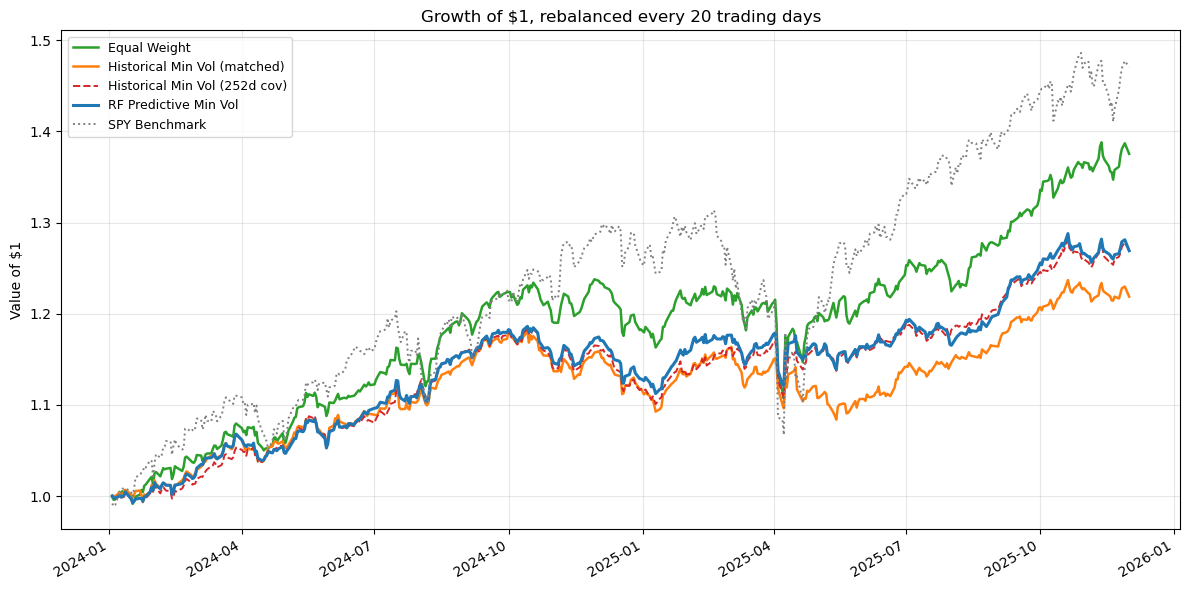

In [23]:
fig, ax = plt.subplots(figsize=(12, 6))

styles = {
    "RF Predictive Min Vol": {"color": "tab:blue", "linewidth": 2.2},
    "Historical Min Vol (matched)": {"color": "tab:orange", "linewidth": 1.8},
    "Historical Min Vol (252d cov)": {"color": "tab:red", "linewidth": 1.4, "linestyle": "--"},
    "Equal Weight": {"color": "tab:green", "linewidth": 1.8},
    "SPY Benchmark": {"color": "gray", "linewidth": 1.4, "linestyle": ":"},
}

for name in daily_returns.columns:
    (1 + daily_returns[name]).cumprod().plot(ax=ax, label=name, **styles.get(name, {}))

ax.set_title(f"Growth of $1, rebalanced every {REBALANCE_EVERY} trading days")
ax.set_ylabel("Value of $1")
ax.set_xlabel("")
ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

### Risk and return, side by side

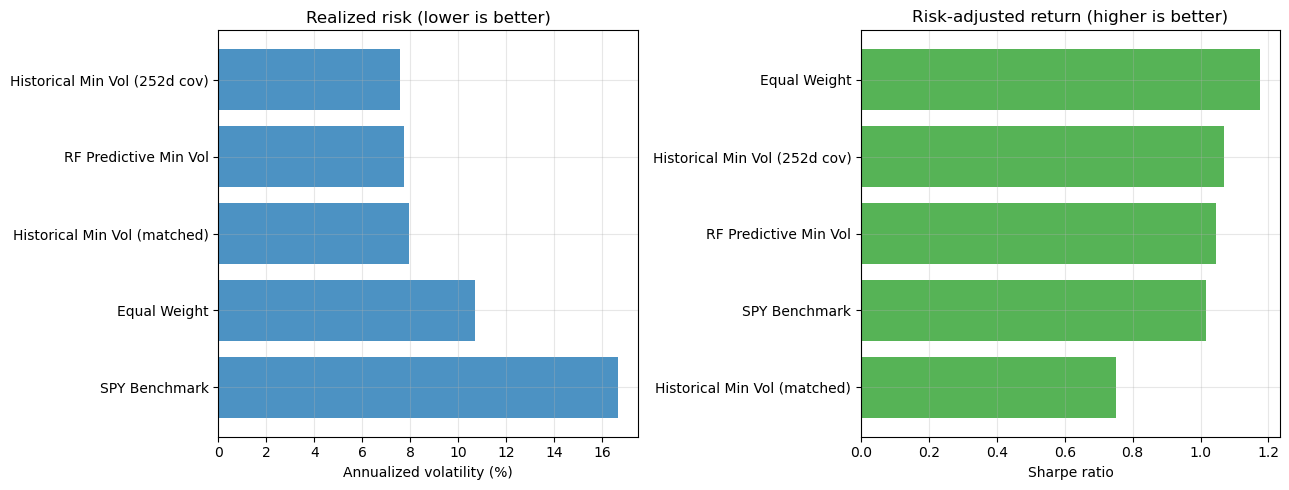

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_order = performance.sort_values("annualized_volatility")

axes[0].barh(plot_order["strategy"], plot_order["annualized_volatility"] * 100,
             color="tab:blue", alpha=0.8)
axes[0].set_xlabel("Annualized volatility (%)")
axes[0].set_title("Realized risk (lower is better)")
axes[0].invert_yaxis()

sharpe_order = performance.sort_values("sharpe_ratio")
axes[1].barh(sharpe_order["strategy"], sharpe_order["sharpe_ratio"],
             color="tab:green", alpha=0.8)
axes[1].set_xlabel("Sharpe ratio")
axes[1].set_title("Risk-adjusted return (higher is better)")

plt.tight_layout()
plt.show()

### Rolling 60-day volatility

The performance table reports one volatility number for the whole period. This shows whether the RF
portfolio's lower risk was persistent or driven by a single calm stretch.

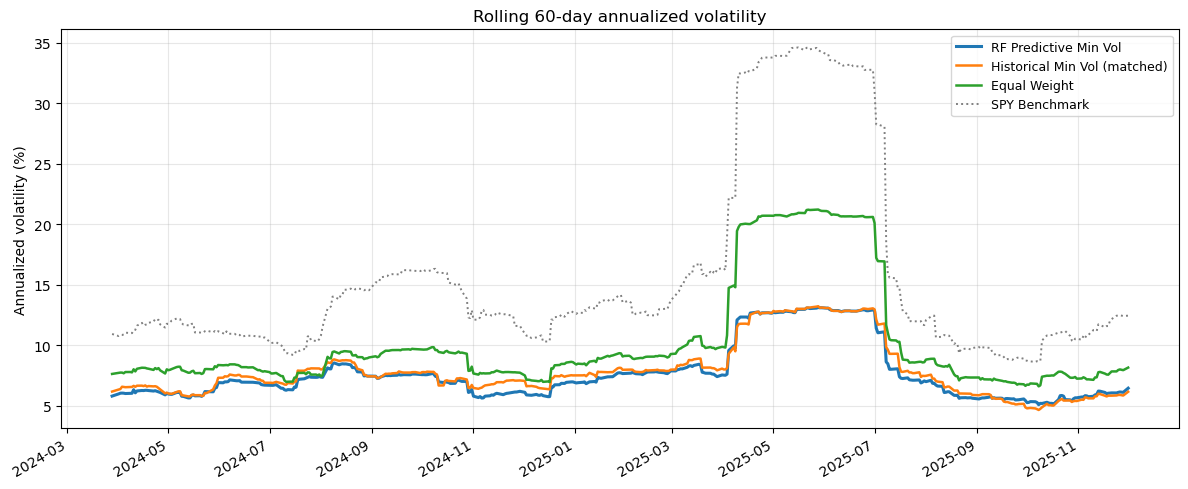

In [25]:
fig, ax = plt.subplots(figsize=(12, 5))

for name in ["RF Predictive Min Vol", "Historical Min Vol (matched)", "Equal Weight", "SPY Benchmark"]:
    rolling = daily_returns[name].rolling(60).std() * np.sqrt(TRADING_DAYS) * 100
    rolling.plot(ax=ax, label=name, **styles.get(name, {}))

ax.set_title("Rolling 60-day annualized volatility")
ax.set_ylabel("Annualized volatility (%)")
ax.set_xlabel("")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## Turnover

Lower turnover means less trading and lower real-world transaction costs. This matters for the
interpretation: a risk model that is both quieter and lower-risk is genuinely more usable.

In [26]:
turnover_rows = []

for name in ["Historical Min Vol (matched)", "Historical Min Vol (252d cov)", "RF Predictive Min Vol"]:
    weights_over_time = pd.DataFrame(weight_history[name]).T.sort_index()
    turnover = weights_over_time.diff().abs().sum(axis=1)

    turnover_rows.append({
        "strategy": name,
        "average_turnover_per_rebalance": turnover.mean(),
    })

pd.DataFrame(turnover_rows)

,strategy,average_turnover_per_rebalance
0,Historical Min Vol (matched),0.6949
1,Historical Min Vol (252d cov),0.1366
2,RF Predictive Min Vol,0.4334


# Part C: Is the Result Stable? (Robustness)

A single backtest with ~25 rebalances is a small sample. Before claiming the Random Forest helps, we
check whether the conclusion survives changing the rebalancing frequency. If the answer flips when we
rebalance every 10 days instead of every 20, we have found noise, not an effect.

This is the check that keeps the notebook honest.

In [27]:
sweep_rows = []

for frequency in [5, 10, 20, 40, 60, 120]:
    sweep_returns, _, _ = run_backtest(frequency)
    sweep_performance = evaluate_strategies(sweep_returns).set_index("strategy")

    sweep_rows.append({
        "rebalance_days": frequency,
        "rf_sharpe": sweep_performance.loc["RF Predictive Min Vol", "sharpe_ratio"],
        "matched_sharpe": sweep_performance.loc["Historical Min Vol (matched)", "sharpe_ratio"],
        "equal_weight_sharpe": sweep_performance.loc["Equal Weight", "sharpe_ratio"],
        "rf_volatility": sweep_performance.loc["RF Predictive Min Vol", "annualized_volatility"],
        "matched_volatility": sweep_performance.loc["Historical Min Vol (matched)", "annualized_volatility"],
    })

frequency_sweep = pd.DataFrame(sweep_rows)
frequency_sweep["sharpe_advantage"] = frequency_sweep["rf_sharpe"] - frequency_sweep["matched_sharpe"]
frequency_sweep["volatility_advantage"] = frequency_sweep["matched_volatility"] - frequency_sweep["rf_volatility"]

frequency_sweep

,rebalance_days,rf_sharpe,matched_sharpe,equal_weight_sharpe,rf_volatility,matched_volatility,sharpe_advantage,volatility_advantage
0,5,1.0669,1.2429,1.1753,0.0741,0.0759,-0.1760,0.0019
1,10,1.0557,1.2287,1.1753,0.0759,0.0766,-0.1730,0.0007
2,20,1.0459,0.7507,1.1753,0.0772,0.0795,0.2952,0.0023
3,40,0.8877,0.9363,1.1753,0.0815,0.0903,-0.0486,0.0088
4,60,1.1143,0.7693,1.1753,0.0795,0.0840,0.3450,0.0046
5,120,0.7980,0.6030,1.1753,0.0874,0.1036,0.1950,0.0162


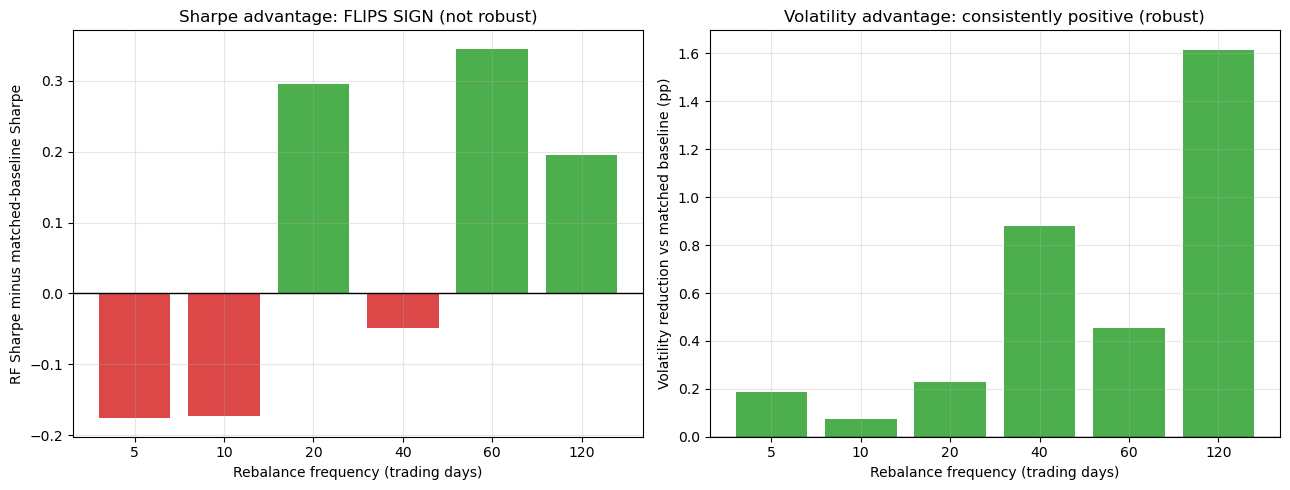

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(frequency_sweep["rebalance_days"].astype(str), frequency_sweep["sharpe_advantage"],
            color=["tab:green" if v > 0 else "tab:red" for v in frequency_sweep["sharpe_advantage"]],
            alpha=0.85)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_xlabel("Rebalance frequency (trading days)")
axes[0].set_ylabel("RF Sharpe minus matched-baseline Sharpe")
axes[0].set_title("Sharpe advantage: FLIPS SIGN (not robust)")

axes[1].bar(frequency_sweep["rebalance_days"].astype(str), frequency_sweep["volatility_advantage"] * 100,
            color=["tab:green" if v > 0 else "tab:red" for v in frequency_sweep["volatility_advantage"]],
            alpha=0.85)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_xlabel("Rebalance frequency (trading days)")
axes[1].set_ylabel("Volatility reduction vs matched baseline (pp)")
axes[1].set_title("Volatility advantage: consistently positive (robust)")

plt.tight_layout()
plt.show()

**Read this carefully — it is the core result of the notebook.**

- The **Sharpe advantage changes sign** across rebalancing frequencies. We cannot claim the Random
  Forest improves risk-adjusted return; with only a handful of rebalances the differences are noise.
- The **volatility advantage is positive at every frequency tested**. The RF risk model reliably
  produces a lower-risk portfolio than the matched historical baseline, and the gap widens as
  rebalancing gets less frequent, which is exactly what we would expect if the model's forecasts
  carry real information that decays over time.

Reporting only the 20-day result would have been cherry-picking. The stable finding is about risk,
not about return.

## What notebook 06's design actually produces

Holding one allocation for the entire period, so we can see the effect of the design choice directly.

In [29]:
hold_forever_returns, _, _ = run_backtest(rebalance_every=None)

hold_forever_performance = evaluate_strategies(hold_forever_returns)
hold_forever_performance

,strategy,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,cumulative_return
0,Historical Min Vol (252d cov),0.1646,0.0768,1.5258,-0.0485,0.3604
1,RF Predictive Min Vol,0.1471,0.0764,1.3046,-0.0529,0.3159
2,Equal Weight,0.1731,0.1070,1.1753,-0.1057,0.3753
3,Historical Min Vol (matched),0.1563,0.0927,1.1752,-0.0681,0.3357
4,SPY Benchmark,0.2162,0.1664,1.0151,-0.1876,0.4705


With a single frozen allocation the ordering is different again, and the strong 252-day sample
covariance baseline does well. Two lessons for the report:

1. **Rebalancing frequency is a real experimental variable**, not a detail. Conclusions about the
   model are not meaningful without stating how often the portfolio was rebalanced.
2. **The choice of historical baseline matters as much as the model.** A well-estimated 252-day
   sample covariance is a much tougher opponent than a 20-day trailing volatility estimate. Beating
   the weak baseline is not the same as beating the strong one.

# Part D: Was the Risk Model Honest?

A minimum-volatility optimizer promises a level of risk. This checks whether that promise was kept:
we compare the volatility each risk model *predicted* for its own portfolio against the volatility
that portfolio *actually realized* over the following holding period.

This is a direct test of the risk model, independent of returns.

In [30]:
risk_forecasts["rf_error"] = (risk_forecasts["rf_predicted"] - risk_forecasts["rf_realized"]).abs()
risk_forecasts["matched_error"] = (risk_forecasts["matched_predicted"] - risk_forecasts["matched_realized"]).abs()

calibration = pd.DataFrame([
    {"risk_model": "RF predicted volatility",
     "mean_predicted": risk_forecasts["rf_predicted"].mean(),
     "mean_realized": risk_forecasts["rf_realized"].mean(),
     "bias": risk_forecasts["rf_predicted"].mean() - risk_forecasts["rf_realized"].mean(),
     "mean_absolute_error": risk_forecasts["rf_error"].mean()},
    {"risk_model": "Historical matched baseline",
     "mean_predicted": risk_forecasts["matched_predicted"].mean(),
     "mean_realized": risk_forecasts["matched_realized"].mean(),
     "bias": risk_forecasts["matched_predicted"].mean() - risk_forecasts["matched_realized"].mean(),
     "mean_absolute_error": risk_forecasts["matched_error"].mean()},
])

print(f"RF risk forecast was closer to reality in "
      f"{(risk_forecasts['rf_error'] < risk_forecasts['matched_error']).sum()} "
      f"of {len(risk_forecasts)} rebalance windows")

calibration

RF risk forecast was closer to reality in 14 of 24 rebalance windows


,risk_model,mean_predicted,mean_realized,bias,mean_absolute_error
0,RF predicted volatility,0.0042,0.0046,-0.0004,0.0010
1,Historical matched baseline,0.0037,0.0047,-0.0010,0.0012


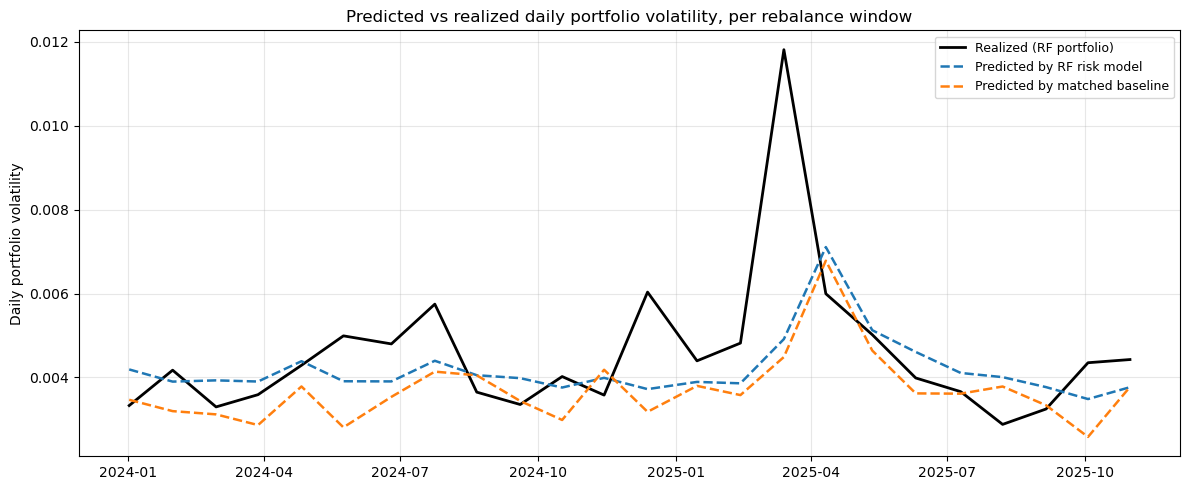

In [31]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(risk_forecasts["rebalance_date"], risk_forecasts["rf_realized"],
        color="black", linewidth=2, label="Realized (RF portfolio)")
ax.plot(risk_forecasts["rebalance_date"], risk_forecasts["rf_predicted"],
        color="tab:blue", linewidth=1.8, linestyle="--", label="Predicted by RF risk model")
ax.plot(risk_forecasts["rebalance_date"], risk_forecasts["matched_predicted"],
        color="tab:orange", linewidth=1.8, linestyle="--", label="Predicted by matched baseline")

ax.set_title("Predicted vs realized daily portfolio volatility, per rebalance window")
ax.set_ylabel("Daily portfolio volatility")
ax.set_xlabel("")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

Both risk models **understate** risk, which is the normal and expected failure mode: they are built
from a correlation matrix estimated in calmer conditions, so they miss the correlation spikes that
occur precisely when markets fall. The relevant comparison is which one understates less. The Random
Forest's bias is substantially smaller, meaning an investor relying on it would have been misled less
about how much risk they were carrying.

This is a concrete, practical benefit that the Sharpe ratio does not capture.

# Save Outputs

Saved so the dashboard, the report, and the final slides can all cite the same numbers rather than
re-deriving them.

In [32]:
performance.to_csv(OUTPUT_PATH / "rebalanced_strategy_performance.csv", index=False)
accuracy.to_csv(OUTPUT_PATH / "forecast_accuracy_vs_baseline.csv", index=False)
per_ticker.to_csv(OUTPUT_PATH / "forecast_accuracy_by_ticker.csv", index=False)
skill.to_csv(OUTPUT_PATH / "forecast_skill_decomposition.csv", index=False)
frequency_sweep.to_csv(OUTPUT_PATH / "rebalance_frequency_sweep.csv", index=False)
calibration.to_csv(OUTPUT_PATH / "risk_model_calibration.csv", index=False)
daily_returns.to_csv(OUTPUT_PATH / "rebalanced_daily_returns.csv")

(1 + daily_returns).cumprod().to_csv(OUTPUT_PATH / "rebalanced_cumulative_returns.csv")

for saved_file in sorted(OUTPUT_PATH.glob("*.csv")):
    print(f"saved {saved_file.name}")

saved forecast_accuracy_by_ticker.csv
saved forecast_accuracy_vs_baseline.csv
saved forecast_skill_decomposition.csv
saved rebalance_frequency_sweep.csv
saved rebalanced_cumulative_returns.csv
saved rebalanced_daily_returns.csv
saved rebalanced_strategy_performance.csv
saved risk_model_calibration.csv


# Conclusions

## 1. The Random Forest is a genuinely better volatility forecaster than the naive baseline

It cuts MAE by roughly 19% and RMSE by roughly 19% against a trailing-20-day-volatility forecast,
wins on 20 of 21 tickers, and the improvement is statistically significant even after accounting for
the overlapping-window autocorrelation that inflates a naive t-test.

**Caveat that belongs in the report:** most of that advantage is *cross-sectional*. The model is good
at knowing which assets are risky and only modestly good at knowing when a given asset's volatility
is about to change. Within-ticker R² is small in absolute terms — though still far better than the
baseline, whose within-ticker R² is strongly negative.

## 2. Predicted volatility does improve risk control

Against a matched baseline that differs only in its volatility input, the RF-driven minimum-volatility
portfolio realized **lower volatility at every rebalancing frequency tested** (5, 10, 20, 40, 60 and
120 days). It also produced **better-calibrated risk forecasts** and required **less turnover**. For a
strategy whose stated objective is minimizing volatility, this is the objective being met.

## 3. Predicted volatility does not reliably improve risk-adjusted return

The Sharpe advantage over the matched baseline **flips sign** depending on rebalancing frequency. With
roughly 25 rebalances over a two-year test period, that is noise. We do not claim a Sharpe improvement,
and the report should not either.

## 4. Equal-weight remains the hardest baseline to beat

No optimized strategy beat naive equal-weighting on Sharpe ratio over this period. Minimum-volatility
optimization did what it promised — it cut portfolio volatility by roughly a quarter — but it gave up
enough return that risk-adjusted performance did not improve. This is a well-known result in the
portfolio literature and it reproduced cleanly in our data.

## 5. Methodology conclusion

Notebook 06's finding that the RF portfolio underperforms is an artifact of using one forecast to set
weights held for two years. Once the portfolio is rebalanced at the model's actual 20-day forecast
horizon, the RF risk model is competitive and superior on risk. **Rebalancing frequency and choice of
baseline change the answer more than the model does**, which is itself worth reporting.